# 8.1 Introdução e Séries de Fourier

Problemas físicos importantes tais como aqueles ligados à condução de calor, à propagação de ondas e à teoria do potencial envolvem duas ou mais variáveis independentes e, portanto, são modelados por meio de Equações Diferenciais Parciais (EDPs).

Uma EDP de ordem $m$ é uma igualdade envolvendo uma função de $n$ variáveis ( $n \geq 2$ ) e suas respectivas derivadas parciais de até ordem $m(m \geq 1)$, ou seja é uma igualdade do tipo

$$F\left(x_1, \ldots, x_n, u, \frac{\partial u}{\partial x_1}, \ldots, \frac{\partial u}{\partial x_n}, \frac{\partial^2 u}{\partial x_1^2}, \frac{\partial^2 u}{\partial x_1 \partial x_2}, \ldots, \frac{\partial^m u}{\partial x_n^m}\right)=0$$

onde $u=u\left(x_1, \ldots, x_n\right)$ e $F$ é uma função qualquer.

As equações diferenciais parciais básicas de condução de calor, propagação de ondas e teoria do potencial, estão associadas a três tipos distintos de fenômenos físicos: processos de difusão, processos oscilatórios e processos independentes do tempo ou estacionários.

Um método importante para resolver equações diferenciais parciais, conhecido como **método de separação de variáveis**, transforma a equação diferencial parcial por um conjunto de equações diferenciais ordinárias. A resolução muitas vezes requer condições iniciais ou de contorno e série em senos e/ou cossenos conhecidas como **séries de Fourier** ([Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/44%5B%3Bvnd.vst.idref%3Dchapter10%5D!/4/406/162/13:44%5BFou%2Crie%5D)).

#### Séries de Fourier

As funçōes

$$
\sin \left(\frac{n \pi x}{L}\right) \quad \mathrm{e} \quad \cos \left(\frac{n \pi x}{L}\right), \quad n=1,2, \ldots,
$$

sāo periódicas com período fundamental $T=2L/n$ e formam, juntamente com a funçāo constante $1$, um conjunto ortogonal no intervalo $[-L,L]$. Assim, toda funçāo periódica de período $2L$ que satisfaça as condiçōes usuais de Fourier pode ser representada por sua **série de Fourier**

$$
f(x) = \frac{a_0}{2}+\sum_{n=1}^{\infty}\left(a_n \cos \left(\frac{n \pi x}{L}\right)+b_n \sin \left(\frac{n \pi x}{L}\right)\right),
$$

com os coeficientes de Fourier de $f(x)$ dados pelas **fórmulas de Euler**

$$a_0=\frac{1}{2 L} \int_{-L}^L f(x) d x,$$
$$a_n=\frac{1}{L} \int_{-L}^L f(x) \cos \frac{n \pi x}{L} d x$$
$$b_n=\frac{1}{L} \int_{-L}^L f(x) \operatorname{sen} \frac{n \pi x}{L} d x
$$

com $n=1,2,3,\dots$ ([Boyce, 2020](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/44%5B%3Bvnd.vst.idref%3Dchapter10%5D!/4/166/2/2)).

Vamos ver alguns exemplos, mas antes vamos importar algumas funções e a constante $\pi$ usano a linha de código abaixo.

In [1]:
from numpy import sin, cos, pi, exp

**Exemplo 8.1.1:** Suponha que existe uma série de Fourier convergindo para a função $f$ definida por

$$
\begin{gathered}
f(x)=\left\{\begin{array}{cc}
-x, & -2 \leq x<0 \\
x, & 0 \leq x<2
\end{array}\right. \qquad \text{com} \qquad f(x+4)=f(x)
\end{gathered}
$$


Vamos ver como são os coeficientes nesta série de Fourier e fazer o gráfico.

In [2]:
# definindo a função f
def f(x):
    if x>=2: 
        return f(x-4)
    if x<-2:
        return f(x+4)
    if (x>=-2)&(x<0): 
        return -x
    if (x>=0)&(x<2): 
        return x

In [3]:
# importando as bibliotecas
import numpy as np
import matplotlib.pyplot as plt

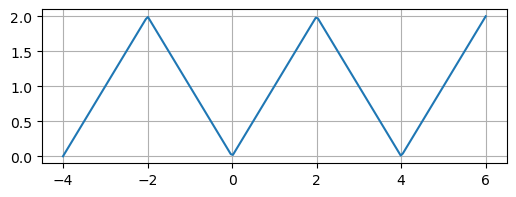

In [4]:
# plotando a função f
x = np.linspace(-4,6,200)
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(x,[f(xi) for xi in x])
plt.grid()

Os coeficientes são dados por 

$$
a_0=\frac{1}{2} \int_{-2}^0(-x) d x+\frac{1}{2} \int_0^2 x d x = 2
$$

$$
a_n=\frac{1}{2} \int_{-2}^0(-x) \cos \left(\frac{n \pi x}{2}\right) d x+\frac{1}{2} \int_0^2 x \cos \left(\frac{n \pi x}{2}\right) dx
=\left\{\begin{array}{cl}
-\frac{8}{(n \pi)^2}, & n \text { ímpar } \\
0, & n \text { par. }
\end{array}\right.
$$

e 

$$
b_n=\frac{1}{2} \int_{-2}^0(-x) \operatorname{sen} \left(\frac{n \pi x}{2}\right) dx+\frac{1}{2} \int_0^2 x\operatorname{sen} \left(\frac{n \pi x}{2}\right)dx=0
$$

Calculando as integrais, substituindo e simplificando, obtemos 
$$
f(x)=1-\frac{8}{\pi^2} \sum_{n=1}^{\infty} \frac{1}{(2 n-1)^2} \cos \left(\frac{(2 n-1) \pi x}{2}\right) .
$$

O gráfico da função e da série de Fourier com 3 termos é mostrado abaixo:

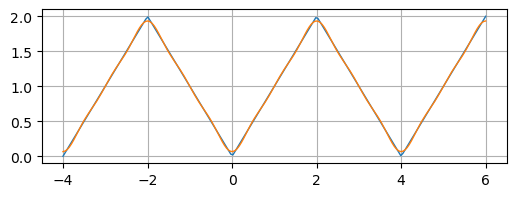

In [5]:
# plotando a função
x = np.linspace(-4,6,200)
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(x,[f(xi) for xi in x], lw=1)

# gerando a série
n_max = 3
soma = np.zeros(len(x))
for n in range(1,n_max+1):
    soma= soma+(1/(2*n-1)**2)*cos((2*n-1)*pi*x/2)
serie = 1-(8/np.pi**2)*soma

# plotando a série
plt.plot(x,serie,lw=1)
plt.grid()

**Exemplo 8.1.2:**
A seguir é mostrado como usar **integração numérica** por meio da função `quad` de `scipy.integrate` para obter uma aproximação por série de Fourier da função do primeiro exemplo. 

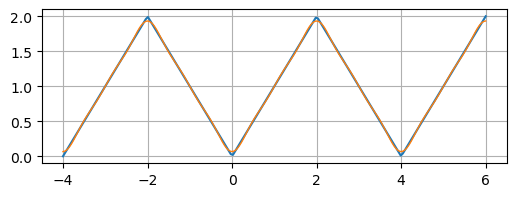

In [6]:
from scipy.integrate import quad

soma = 1

for n in range(1,6):
    An = (1/2)*(quad(lambda x: -x*cos(n*pi*x/2),-2,0)[0] +\
                    quad(lambda x: x*cos(n*pi*x/2), 0,2)[0])
    Bn = (1/2)*(quad(lambda x: -x*sin(n*pi*x/2),-2,0)[0] +\
                    quad(lambda x: x*sin(n*pi*x/2), 0,2)[0])
    soma += An*cos(n*pi*x/2) + Bn*sin(n*pi*x/2)
    
fig, ax = plt.subplots(figsize=(6,2))
plt.plot(x,[f(xi) for xi in x])
plt.plot(x,soma, lw=1)
plt.grid()

**Exemplo 8.1.3:** Os coeficientes de Fourier da onda retangular periódica 

$$
f(x)=\left\{\begin{array}{rcc}
-2 & \text { se } & -\pi<x<0 \\
2 & \text { se } & 0<x<\pi
\end{array} \quad \text { e } \quad f(x+2 \pi)=f(x) .\right.
$$

São tais que $a_0 = 0$, $a_n=0$. Além disso, quando $n$ é par, $b_n=0$, quando $n$ é impar, $b_n=\frac{8}{n\pi}$. Assim a série de Fourier é dada por

$$
\frac{8}{\pi}\left(\operatorname{sen} x+\frac{1}{3} \operatorname{sen} 3 x+\frac{1}{5} \operatorname{sen} 5 x+\cdots\right).
$$

Podemos plotar o gráfico da função e da série como é mostrado a seguir.

In [7]:
# definindo a função f
def f(x):
    if x>=pi: 
        return f(x-2*pi)
    if x<-pi:
        return f(x+2*pi)
    if (x>=-pi)&(x<0): 
        return -2
    if (x>=0)&(x<pi): 
        return 2

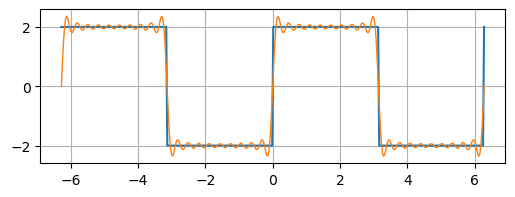

In [8]:
xi = np.linspace(-2*pi, 2*pi, 400)
n_max = 20
soma = 0
for n in range(1, n_max, 2):
    soma += (8/np.pi)*sin(n*xi)/n

fig, ax = plt.subplots(figsize=(6,2))
plt.plot(xi,[f(x) for x in xi])
plt.plot(xi, soma, lw = 1)
plt.grid()
plt.show()

**Exemplo 8.1.4:** Usando integração numérica para obter uma aproximação por série de Fourier da função $f(x)=sen(e^x)$ no intervalo $(-3,3)$. Plote o gráfico da função $f$ e da função aproximadora com 10 termos.

In [9]:
f = lambda x: sin(exp(x))

In [10]:
def fourier(f,N):
    n=0
    A0 = 1/np.pi * quad(lambda x: f(x)*np.cos(n*x),-np.pi,np.pi)[0]
    
    xi = np.linspace(-3,3,301)
    yi = []

    soma = A0/2

    for x in xi:
        soma = A0/2
        for n in range(1,N):
            An = 1/np.pi * quad(lambda x: f(x)*np.cos(n*x),-np.pi,np.pi)[0]
            Bn = 1/np.pi * quad(lambda x: f(x)*np.sin(n*x),-np.pi,np.pi)[0]
            soma +=  An*np.cos(n*x)+Bn*np.sin(n*x)
        yi.append(soma)
    
    fig, ax = plt.subplots(figsize=(6,2))
    plt.plot(xi,yi, xi, f(xi))
    plt.grid()

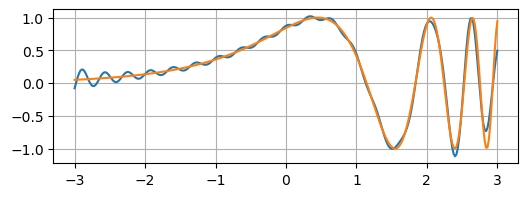

In [11]:
fourier(f,20)

Agora vamos estudar a relação da série de Fourier com a solução da equação do calor unidimensional.

#### Condução de calor em uma barra

Considere o problema de condução de calor em uma barra de seção reta uniforme, feita de material homogêneo, com um eixo $x$ coincidindo com o eixo da barra, sendo $x = 0$ e $x = L$ as extremidades. 

Suponha que os lados da barra estão perfeitamente isolados e que as dimensões da seção reta são tão pequenas que a temperatura $u$ pode ser considerada constante em qualquer seção. Então, $u$ só depende da coordenada axial $x$ e do instante $t$.

![](https://raw.githubusercontent.com/tiagoburiol/MatComp_IV/refs/heads/main/imagens/barra.png){width=400px}

(Fonte: [Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/44%5B%3Bvnd.vst.idref%3Dchapter10%5D!/4/406/162/13:44%5BFou%2Crie%5D)) 

A variação da temperatura na barra é governada pela **equação diferencial parcial** (EDP) conhecida como a **equação do calor**, que pode ser escrita na forma

$$\alpha^2 u_{xx} = u_t, \quad 0<x<L \quad\text{e}\quad t>0 ,$$  

em que  $\alpha^2$ é difusividade térmica, uma constante que depende do material. Alguns valores típicos são mostrados como exemplo na tabela abaixo

Material     |cm$^2$/s| 
-------------|--------|
Cobre        |18,5    |
Aluminio     |0,8418  |
Ferro        |0,23    |
Aço carbono  |0,1172  |
Aço inox     |0,03352 |
Madeira pinus|0,00082 |

O problema fundamental de condução de calor é encontrar $u(x, t)$ que satisfaz a equação diferencial para $0 < x < L$ e para $t > 0$, com a condição inicial 
$$
u(x, 0)=f(x), \quad 0 \leq x \leq L,
$$
quando $t = 0$ e as condições de contorno $T_1$ em $x = 0$ e $T_2$ em $x = L$. Começaremos com as contições de contorno $T_1=T_2=0$,então,

$$u(0, t)=0, \quad u(L, t)=0, \quad t>0.$$

Pelo **método de separação de variáveis**, iniciamos supondo que $u(x, t)$ é um produto de duas outras funções, uma dependendo só de $x$ e a outra dependendo só de $t$. Assim,

$$
u(x, t)=X(x) T(t) .
$$

Substituindo na equação diferencial , obtemos

$$
\alpha^2 X^{\prime \prime}(x) T(t)=X(x) T^{\prime}(t)
$$

ou, simplesmente 
$$
\alpha^2 X^{\prime \prime} T=X T^{\prime},
$$
Dividindo os dois lados por $\alpha^2 X T$, obtemos a equação equivalente

$$
\frac{X^{\prime \prime}}{X}=\frac{1}{\alpha^2} \frac{T^{\prime}}{T},
$$


Para que a equação acima seja válida para cada ponto $(x, t)$ em $0 < x < L$, $t > 0$, é preciso que ambos os lados sejam iguais à mesma constante, então escrevemos

$$
\frac{X^{\prime \prime}}{X}=\frac{1}{\alpha^2} \frac{T^{\prime}}{T}=-\lambda
$$
Obtemos, então, as duas equações diferenciais ordinárias a seguir para $X(x)$ e $T(t)$ :

$$X^{\prime \prime}+\lambda X=0 \quad \quad \text{e} \quad \quad T^{\prime}+\alpha^2 \lambda T=0$$
Substituindo $u(x, t)$ na condição de contorno em $x=0$, obtemos $u(0, t)=X(0) T(t)=0$, 
o que leva a $X(0)=0$.  A condição de contorno em $x = L$ implica que
$X(L)=0$.

As únicas soluções não triviais de $X^{\prime \prime}+\lambda X=0$ sob as condições $X(0)=0$ e $X(L)=0$, são as autofunções

$$
X_n(x)=\operatorname{sen}\left(\frac{n \pi x}{L}\right), \quad n=1,2,3,\ldots$$

Associadas aos autovalores
$$\lambda_n=\frac{n^2 \pi^2}{L^2}, \quad n=1,2,3,\ldots
$$

Voltando para a equação para $T^{\prime}+\alpha^2 \lambda T=0$ e substituindo $\lambda$ por $n^2 \pi^2 / L^2$, temos

$$
T^{\prime}+\frac{n^2 \pi^2 \alpha^2}{L^2} T=0
$$
Logo, $T(t)$ é proporcional a $e^{-n^2 \pi^2 \alpha^2 t / L^2}$. Portanto, multiplicando as soluções, e desprezando as constantes arbitrárias de proporcionalidade, concluímos que as funções

$$
u_n(x, t)=e^{-n^2 \pi^2 \alpha^2 t / L^2} \operatorname{sen}\left(\frac{n \pi x}{L}\right), \quad n=1,2,3, \ldots
$$

são as soluções fundamentais do problema da condução do calor $\alpha^2 u_{x x}=u_t, \quad 0<x<L, \quad t>0$ com as condições de contorno $u(0, t)=0, \quad u(L, t)=0, \quad t>0$.

Formando combinações lineares do conjunto fundamental de soluções da equação diferencial obtemos uma solução na forma de uma série infinita

$$
u(x, t)=\sum_{n=1}^{\infty} c_n u_n(x, t)=\sum_{n=1}^{\infty} c_n e^{-n^2 \pi^2 \alpha^2 t / L^2} \operatorname{sen}\left(\frac{n \pi x}{L}\right),
$$

em que os coeficientes $c_n$ ainda estão indeterminados.
Para satisfazer a condição inicial $u(x, 0)=f(x), \quad 0 \leq x \leq L$, temos que ter

$$
u(x, 0)=\sum_{n=1}^{\infty} c_n \operatorname{sen}\left(\frac{n \pi x}{L}\right)=f(x)
$$

Assim, precisamos escolher os coeficientes $c_n$ tais que a série em senos na equação acima convirja para a distribuição inicial de temperatura $f (x)$ para $0 ≤ x ≤ L$. Ou seja, são os coeficientes da  série de Fourier em senos de $f$, dados por 

$$
c_n=\frac{2}{L} \int_0^L f(x) \operatorname{sen}\left(\frac{n \pi x}{L}\right) d x
$$

**Exemplo 8.1.5:** Encontre a temperatura $u(x, t)$ em qualquer instante em uma barra de metal com 50 cm de comprimento $\alpha^2 = 1$, isolada nos lados, inicialmente a uma temperatura uniforme de 20 °C em toda a barra e cujas extremidades são mantidas a 0 °C para todo t > 0.

Fazendo $L=50$ e $f(x)=20$ para $0<x<50$, a solução será dada por 

$$u_n(x,t) = \sum_{n=1}^\infty c_n e^{-n^2\pi^2t/2500} \operatorname{sen}\left(\frac{n\pi x}{50} \right)$$

com 

$$c_n = \frac{2}{50} \int_{0}^{50} 20 \operatorname{sen}\left(\frac{n\pi x}{50} \right) dx = \frac{40}{n\pi}(1-\cos n\pi) = \begin{cases}
\frac{80}{n\pi}, \,\,\,  n \,\,\,  ímpar; \\
0, \,\,\, n  \,\,\, par.\\ 
\end{cases}$$

Substituindo, a solução fica

$$u_n(x,t) =\frac{80}{\pi} \sum_{n=1,3,5,...}^\infty \frac{1}{n}e^{-n^2\pi^2t/2500} \operatorname{sen}\left(\frac{n\pi x}{50} \right)$$


O fator exponencial com potência negativa em cada termo da série faz com que ela convirja rapidamente, exceto para valores pequenos de $t$. Portanto, resultados precisos podem ser obtidos, em geral, usando-se apenas alguns poucos termos da série.

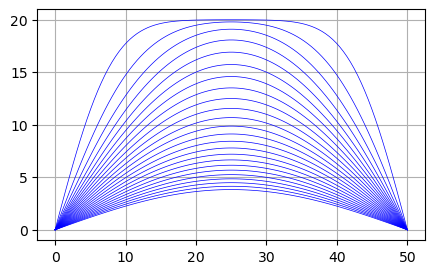

In [12]:
def u(x,t,N):
    soma = 0
    for n in range(1,N,2):
        soma += (1/n)*exp((-n**2*pi**2*t)/2500)*sin(n*pi*x/50)
    return (80/pi)*soma

N = 10
x = np.linspace(0,50,100)
fig, ax = plt.subplots(figsize=(5,3))
for t in range(20,500,20):
    plt.plot(x, [u(xi,t,N) for xi in x],
             color ='b', linewidth = 0.5)
plt.grid()

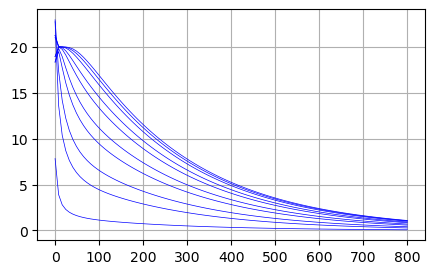

In [13]:
N = 10
t = np.linspace(0,800,100)
fig, ax = plt.subplots(figsize=(5,3))
for x in range(1,50,5):
    plt.plot(t, [u(x,ti,N) for ti in t],
             color ='b', linewidth = 0.5)
plt.grid()

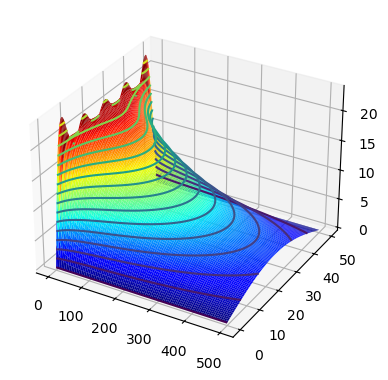

In [14]:
from matplotlib import cm  # color map
from mpl_toolkits.mplot3d import Axes3D

    
x, t = np.meshgrid(np.linspace(0, 50, 101),
                   np.linspace(0, 500, 101))

N = 10 
ui = x.copy()
for i in range(len(x)):
    for j in range(len(t)):
        ui[i,j] = u(x[i,j],t[i,j],N)


fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(211,projection="3d")
ax.plot_surface(t, x, ui, rstride=1, cstride=1, cmap=cm.jet)
ax.contour(t, x, ui, 20,linewidths=1.5)
    
plt.show()

### Equação da onda

Dada a EDP

$$
\frac{\partial^2 u}{\partial t^2}=c^2 \frac{\partial^2 u}{\partial x^2}
$$

sob as condições 

$$
u(0, t)=0, \quad u(L, t)=0 \quad \text { para todo } t \quad \text { e}
$$
$$
u(x, 0)=f(x), \quad u_t(x, 0)=g(x) \quad(0 \leqq x \leqq L)
$$

Sabe-se que a solução analítica é dada por 

$$
u(x, t)=\sum_{n=1}^{\infty} u_n(x, t)=\sum_{n=1}^{\infty}\left(B_n \cos \lambda_n t+B_n^* \operatorname{sen} \lambda_n t\right) \operatorname{sen} \frac{n \pi}{L} x
$$

com $\lambda_n =\frac{c n \pi}{L}$ e 

$$B_n=\frac{2}{L} \int_0^L f(x) \operatorname{sen} \frac{n \pi x}{L} d x \quad \text{e} \quad B_n^*=\frac{2}{c n \pi} \int_0^L g(x) \operatorname{sen} \frac{n \pi x}{L} d x$$

**Exemplo 8.1.6:** A solução da equação da onda correspondente à deflexão inicial triangular

$$
f(x)=\left\{\begin{array}{lll}
\frac{2 k}{L} x & \text { se } & 0<x<\frac{L}{2} \\
\frac{2 k}{L}(L-x) & \text { se } & \frac{L}{2}<x<L
\end{array}\right.
$$

e à velocidade inicial nula. 

A solução será uma série dada por 

$$u(x, t)=\frac{8 k}{\pi^2}\left[\frac{1}{1^2} \operatorname{sen} \frac{\pi}{L} x \cos \frac{\pi c}{L} t-\frac{1}{3^2} \operatorname{sen} \frac{3 \pi}{L} x \cos \frac{3 \pi c}{L} t+\cdots\right]$$

Considerando $c=1$, $k = 1$ e $L = 2$ e plote gráficos para alguns valores de $t$.

In [15]:
import sympy as sp
from sympy import pi
x, t, c, L, k, i = sp.symbols('x t c L k i')
n = sp.symbols('n', integer=True,positive=True)

lamb = c*n*pi/L

f1 = 2*k*x/L
f2 = 2*k*(L-x)/L

Bn = (2/L)*(sp.integrate(f1*sp.sin((n*pi*x)/L),(x,0,L/2)) + \
            sp.integrate(f2*sp.sin((n*pi*x)/L), (x,L/2,L)))


In [16]:
g = 0

Bna = (2/(c*n*pi))*(sp.integrate(g*sp.sin((n*pi*x)/L),(x,0,L)))

display(Bna)

0

In [17]:
un = (Bn*sp.cos(lamb*t) + Bna*sp.sin(lamb*t))*sp.sin(n*pi*x/L)
display(sp.simplify(un))

8*k*sin(pi*n/2)*sin(pi*n*x/L)*cos(pi*c*n*t/L)/(pi**2*n**2)

In [18]:
for i in range(1,7):
    display(un.subs(n,i))

8*k*sin(pi*x/L)*cos(pi*c*t/L)/pi**2

0

-8*k*sin(3*pi*x/L)*cos(3*pi*c*t/L)/(9*pi**2)

0

8*k*sin(5*pi*x/L)*cos(5*pi*c*t/L)/(25*pi**2)

0

In [19]:
un = un.subs({c: 1, k: 1, L: 2})
display(un)

8*sin(pi*n/2)*sin(pi*n*x/2)*cos(pi*n*t/2)/(pi**2*n**2)

In [20]:
u = sp.lambdify((n,x,t), un)

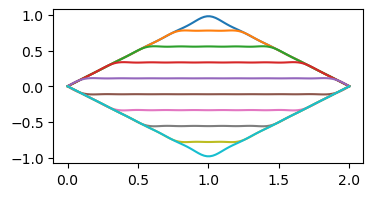

In [21]:
xi = np.linspace(0,2,100)
ui = np.zeros(len(xi))

fig, ax = plt.subplots(figsize=(4,2))

for ti in np.linspace(0,2,10):
    ui = np.zeros(len(xi))
    for ni in range(1,20):
        ui += u(ni,xi,ti)
    plt.plot(xi,ui)
#plt.grid()
plt.show()

### Exercícios

(Fonte: [Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/44%5B%3Bvnd.vst.idref%3Dchapter10%5D!/4/406/162/13:44%5BFou%2Crie%5D))

---

> **1.** Encontre a solução do problema de condução de calor
>
> $$ \begin{aligned}
 & 100 u_{x x}=u_t, \quad 0<x<1, \quad t>0 \\
 & u(0, t)=0, \quad u(1, t)=0, \quad t>0 \\
 & u(x, 0)=\operatorname{sen}(2 \pi x)-\operatorname{sen}(5 \pi x), \quad 0 \leq x \leq 1
 \end{aligned}$$

---

> **2.** Encontre a solução do problema de condução de calor
>
> $$ \begin{aligned}
 & u_{x x}=4 u_t, \quad 0<x<2, \quad t>0 \\
 & u(0, t)=0, \quad u(2, t)=0, \quad t>0 \\
 & u(x, 0)=2 \operatorname{sen}(\pi x / 2)-\operatorname{sen}(\pi x)+4 \operatorname{sen}(2 \pi x), \quad 0 \leq x \leq 2
 \end{aligned}$$

---

> Considere a condução de calor em uma barra com 40 cm de comprimento cujas extremidades são mantidas à temperatura $0{ }^{\circ} \mathrm{C}$ para todo $t>0$. Em cada um dos Problemas 3 a 6, encontre uma expressão para a temperatura $u(x, t)$ quando a distribuição de temperatura inicial na barra for igual à função dada. Suponha que $\alpha^2=1$
>
> **3.** $u(x, 0)=50, \quad 0<x<40$
>
> **4.** $u(x, 0)=\left\{\begin{array}{lrl}x, & 0 & \leq x<20 \\ 40-x, & 20 & \leq x \leq 40\end{array}\right.$
>
> **5.** $u(x, 0)=\left\{\begin{array}{rrl}0, & 0 & \leq x<10 \\ 50, & & 10 \leq x \leq 30 \\ 0, & & 30<x \leq 40\end{array}\right.$
>
> **6.** $u(x, 0)=x, \quad 0 \leq x<40$

---

> **7.** Considere novamente a barra do Problema 3. Para $t = 5$ e $x = 20$, determine quantos termos são necessários para encontrar a solução correta até três casas decimais. Um modo razoável de fazer isso é encontrar $n$ tal que a inclusão de mais um termo não muda as três primeiras casas decimais de $u(20, 5)$. Repita para $t = 20$ e $t = 80$. Chegue a alguma conclusão sobre a velocidade de convergência da série que representa $u(x, t)$.
>
> **8.** Repita o Problema 7 para a barra no Problema 4.
>
> **9.** Repita o Problema 7 para a barra no Problema 5.
>
> **10.** Repita o Problema 7 para a barra no Problema 6.

---